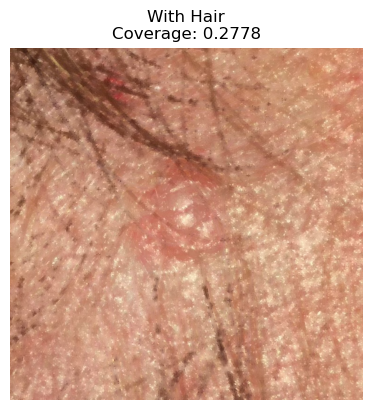

In [26]:
import cv2
import matplotlib.pyplot as plt
def hair_coverage(img_gray):
    # generate hair mask using BlackHat filtering
    kernel = cv2.getStructuringElement(cv2.MORPH_CROSS, (5, 5))
    blackhat = cv2.morphologyEx(img_gray, cv2.MORPH_BLACKHAT, kernel)
    _, hair_mask = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)

    # total_area: number of pixels in the image
    total_area = img_gray.shape[0] * img_gray.shape[1]
    
    # hair_area: count of non-zero (white) pixels in the mask
    hair_area = cv2.countNonZero(hair_mask)
    
    # coverage: ratio of hair pixels to total pixels
    coverage = hair_area / total_area
    
    return round(coverage, 4)

def removeHair_auto(img_org, img_gray):
    # Calculate hair coverage
    coverage = hair_coverage(img_gray)

    # Set parameters based on coverage (Fixes "kernel_size not defined")
    if coverage > 0.05: # High coverage
        kernel_size = 9
        threshold = 10
        radius = 5
    else:               # Low coverage
        kernel_size = 5
        threshold = 15
        radius = 3

    # kernel for the morphological filtering
    kernel = cv2.getStructuringElement(cv2.MORPH_CROSS, (kernel_size, kernel_size))

    # perform the blackHat filtering on the grayscale image to find the hair contours
    blackhat = cv2.morphologyEx(img_gray, cv2.MORPH_BLACKHAT, kernel)

    # intensify the hair contours in preparation for the inpainting algorithm
    _, mask = cv2.threshold(blackhat, threshold, 255, cv2.THRESH_BINARY)

    # inpaint the original image depending on the mask
    img_out = cv2.inpaint(img_org, mask, radius, cv2.INPAINT_TELEA)

    return blackhat, mask, img_out


img_path_hair = '../data/imgs/PAT_21_31_965.png'
img_org_hair = cv2.imread(img_path_hair)
img_gray_hair = cv2.cvtColor(img_org_hair, cv2.COLOR_BGR2GRAY)

coverage_hair = hair_coverage(img_gray_hair)


# Test the auto hair removal function
_, _, img_out_1 = removeHair_auto(img_org_hair, img_gray_hair)


plt.figure(figsize=(10,5))
plt.subplot(1,2,1)

plt.imshow(cv2.cvtColor(img_out_1, cv2.COLOR_BGR2RGB))
plt.title(f'With Hair\nCoverage: {coverage_hair}')
plt.axis('off')


plt.show()



# USE ANNOTATIONS 1 = 0.3 AND CHECK HOW IS IT DOIGN


# EXTRACCT PENMARKS BEFORE DOING FEATURE ?????

In [27]:
import pandas as pd

ans = pd.read_csv('../data/annotations_combined.csv')


ans = ans[['img_id' , 'hair_1', 'hair_2', 'hair_3', 'hair_4' ]].dropna()
ans['hair'] = round(( ans['hair_1'] + ans['hair_2'] + ans['hair_3'] + ans['hair_4'] ) / 4 / 3, 4)

ans

,img_id,hair_1,hair_2,hair_3,hair_4,hair
0,PAT_1431_1495_511.png,2.0,1.0,2.0,1.0,0.5000
1,PAT_2051_4356_460.png,2.0,1.0,1.0,1.0,0.4167
2,PAT_1255_876_939.png,0.0,0.0,0.0,0.0,0.0000
3,PAT_963_1820_823.png,1.0,1.0,1.0,0.0,0.2500
4,PAT_419_832_706.png,0.0,0.0,0.0,0.0,0.0000
...,...,...,...,...,...,...
1632,PAT_1989_4061_934.png,0.0,0.0,0.0,0.0,0.0000
1633,PAT_2036_4281_271.png,3.0,3.0,3.0,3.0,1.0000
1634,PAT_2046_4323_762.png,3.0,3.0,3.0,3.0,1.0000
1635,PAT_2085_4506_726.png,2.0,2.0,2.0,2.0,0.6667


In [38]:
imgs_path = "../data/imgs/"

import os

df = pd.read_csv('../data/metadata.csv')
image_id = df["img_id"].tolist()


def hair():

    features = []
    imgs = []
    for files in image_id:
        file_im = imgs_path + files

        img_org_hair = cv2.imread(file_im)
        img_gray_hair = cv2.cvtColor(img_org_hair, cv2.COLOR_BGR2GRAY)
        
        features.append(hair_coverage(img_gray_hair))
        imgs.append(files)
    return features, imgs


feat, im = hair()

feat



[0.0007,
 0.0021,
 0.0138,
 0.0,
 0.007,
 0.1677,
 0.1799,
 0.0479,
 0.0009,
 0.1661,
 0.0293,
 0.016,
 0.0315,
 0.0043,
 0.0045,
 0.0086,
 0.005,
 0.0012,
 0.0002,
 0.0153,
 0.0022,
 0.001,
 0.0446,
 0.0024,
 0.0015,
 0.0679,
 0.0049,
 0.123,
 0.0039,
 0.0002,
 0.0112,
 0.0093,
 0.0098,
 0.0004,
 0.0434,
 0.1646,
 0.0206,
 0.0005,
 0.0002,
 0.0002,
 0.0335,
 0.0915,
 0.0,
 0.0027,
 0.1692,
 0.0785,
 0.0453,
 0.0004,
 0.0119,
 0.0119,
 0.0005,
 0.014,
 0.0202,
 0.0388,
 0.3684,
 0.0934,
 0.1133,
 0.0041,
 0.0,
 0.0016,
 0.0052,
 0.0076,
 0.0006,
 0.0017,
 0.1122,
 0.006,
 0.0026,
 0.0007,
 0.0102,
 0.0077,
 0.0008,
 0.07,
 0.0454,
 0.0043,
 0.0001,
 0.0309,
 0.0041,
 0.0415,
 0.0001,
 0.001,
 0.017,
 0.0345,
 0.0059,
 0.0109,
 0.0029,
 0.0015,
 0.0002,
 0.1559,
 0.0024,
 0.0199,
 0.02,
 0.0018,
 0.0029,
 0.0016,
 0.0007,
 0.0024,
 0.005,
 0.0008,
 0.0,
 0.0348,
 0.1926,
 0.0108,
 0.0026,
 0.0027,
 0.0276,
 0.0816,
 0.0206,
 0.0166,
 0.0087,
 0.0707,
 0.0045,
 0.0032,
 0.0056,
 0.0001,
